### Graph I

In [4]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [20]:
class AgentState(TypedDict):
    message: str


def greeting_node(state: AgentState) -> AgentState:

    state['message'] = "Heyt " + state['message'] + ", how is your day going?"
    return state

In [21]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()


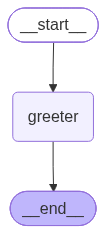

In [22]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({"message": "Bob"})

In [ ]:
result

{'message': 'Heyt Bob, how is your day going?'}

### Graph II

In [26]:
from typing import List, TypedDict
from langgraph.graph import StateGraph

In [61]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str
    operation: str

def process_values(state: AgentState) -> AgentState:
    
    print(state)

    result = 0
    if state["operation"] == "*":
        result+=1
        for v in state["values"]:
            result*=v
    if state["operation"] == "+":
        for v in state["values"]:
            result+=v

    state["result"] = f"Hi there {state['name']}! Your answer = {result}"

    print(state)
    
    return state

In [62]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

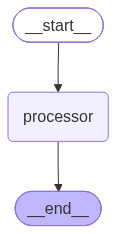

In [63]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [65]:
result = app.invoke({"values":[1, 2, 3, 4], "name": "Carlos", "operation": "+"})

{'values': [1, 2, 3, 4], 'name': 'Carlos', 'operation': '+'}
{'values': [1, 2, 3, 4], 'name': 'Carlos', 'operation': '+', 'result': 'Hi there Carlos! Your answer = 10'}


In [66]:
result['result']

'Hi there Carlos! Your answer = 10'